## Save Pickle

In [1]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import torch
from torch.utils.data import DataLoader
from boilerplate.dataloader import SemisupervisedDataset
from tqdm import tqdm
import tifffile as tiff
import torch
import torch.nn.functional as F
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from numpy.linalg import norm
from openTSNE import TSNE
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import pairwise_distances
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")

In [ ]:
best_checkpoint = "/group/jug/Sheida/HVAE/segmentation/test/model_supervised/segmentation_best_vae.net"
patch_size = 64
label_size = 1
mode = 'semisupervised'
n_classes = 4
batch_size = 1

In [ ]:
data_dir = "/group/jug/Sheida/pancreatic beta cells/download/"
keys = ["high_c1", "high_c2", "high_c3"]

img_paths = [os.path.join(data_dir + key + f"/{key}_source.tif") for key in keys]
lbl_paths = [os.path.join(data_dir + key + f"/{key}_gt.tif") for key in keys]
imgs = {key: tiff.imread(path).astype(np.float16) for key, path in zip(keys, img_paths)}
lbls = {key: tiff.imread(path).astype(np.float16) for key, path in zip(keys, lbl_paths)}
train_idx = {}
np.random.seed(42)
for key in keys:
    # Create a mask for valid indices where labels are not all -1
    # -1 indicates outside of the cell
    
    valid_indices = np.where(~np.all(lbls[key] == -1, axis=(1, 2)))[0]
    total_samples = valid_indices.shape[0]
    np.random.shuffle(valid_indices)  # Shuffles in place

    # Compute split index
    split_idx = int(0.85 * total_samples)

    # Split the indices
    train_idx[key] = valid_indices[:split_idx]

# compute mean and std of the data
all_elements = np.concatenate([imgs[key][train_idx[key]].flatten() for key in keys])
data_mean = np.mean(all_elements)
data_std = np.std(all_elements.astype(np.float32))

# normalizing the data
for key in tqdm(keys, "Normalizing data"):
    imgs[key] = (imgs[key] - data_mean) / data_std

train_set = SemisupervisedDataset(
    images=imgs,
    labels=lbls,
    patch_size=patch_size,
    label_size=label_size,
    mode=mode,
    n_classes=n_classes,
    ignore_lbl=-1,
    indices_dict=train_idx,
)

In [ ]:
model = torch.load(best_checkpoint, weights_only=False)
model.update_mode(mode)
model.eval()

for patch in tqdm(DataLoader(train_set, batch_size=batch_size), desc="Evaluating on training set"):
    labels = patch[1].view(-1,1).squeeze(-1).to(device)
    patch = patch[0].float().squeeze(0).to(device)
    with torch.no_grad():
        output = model(patch, labels)
        
        break

In [ ]:
output.keys()

In [ ]:
output['pi'].shape

In [ ]:
type(output['mu'])

In [ ]:
output['mu'][0].shape, output['mu'][1].shape, output['mu'][2].shape

In [ ]:
all_rows = []

for anchor_id, batch in tqdm(enumerate(DataLoader(train_set, batch_size=batch_size)), desc="Evaluating on training set"):

    group = train_set.groups[anchor_id]  # dict with keys: name, z, coords, labels
    name   = group['name']
    z_idx  = group['z']
    coords = group['coords']   # list of 8 (y,x)
    group_labels = group['labels']   # list of 8

    
    labels = batch[1].view(-1,1).squeeze(-1).to(device)
    batch = batch[0].float().squeeze(0).to(device)
    with torch.no_grad():
        
        output = model(batch, labels)

        pi = output['pi']               # (8,4)
        mus = output['mu']             # list of 3 tensors
        z   = torch.cat(
                [F.adaptive_avg_pool2d(x, (1,1)).flatten(1) for x in mus],
                dim=1
            )                          # (8,latent_dim)
        z   = F.normalize(z, dim=1)

        for n in range(8):
            row = {
                'anchor_id': anchor_id,
                'name'     : name,
                'z'        : z_idx,
                'y'        : coords[n][0],
                'x'        : coords[n][1],
                'label'    : group_labels[n],
                'neighbor_index': n,
                'pi'       : pi[n].detach().cpu().numpy(),    # (4,)
                'latent'        : z[n].detach().cpu().numpy(),     # (latent,)
            }
            all_rows.append(row)

# 5. --> DataFrame --> pickle
df = pd.DataFrame(all_rows)
df.to_pickle("dataset.pkl")
print("saved to dataset.pkl")


In [ ]:
def compute_all_pair_distances(df):
    """
    Returns a new DataFrame with one row for each (anchor, target) pair:
    - anchor_id
    - anchor_label
    - target_label
    - pixel_dist
    - latent_dist
    """

    rows = []
    anchors = df[df['neighbor_index']==0]  # only anchors

    for _, ref in anchors.iterrows():
        ref_anchor_id = ref['anchor_id']
        ref_name      = ref['name']
        ref_pos       = np.array([ref['z'], ref['y'], ref['x']], float)
        ref_latent    = ref['latent']
        ref_label     = ref['label']

        # local subset: neighbors + other anchors of same image
        neighbors = df[df['anchor_id'] == ref_anchor_id]
        others    = anchors[(anchors['name']==ref_name) & (anchors['anchor_id']!=ref_anchor_id)]
        subset = pd.concat([neighbors, others], ignore_index=True)

        for _, r in subset.iterrows():
            pos_r = np.array([r['z'], r['y'], r['x']], float)
            latent_r = r['latent']

            rows.append({
                'anchor_id'    : ref_anchor_id,
                'anchor_label' : ref_label,
                'target_label' : r['label'],
                'pixel_dist'   : norm(pos_r - ref_pos),
                'latent_dist'  : norm(latent_r - ref_latent),
            })

    dist_df = pd.DataFrame(rows)
    return dist_df


In [ ]:
df = pd.read_pickle("dataset.pkl")
dist_df = compute_all_pair_distances(df)
dist_df.to_pickle("distance_table.pkl")

In [ ]:
# 1. Load dataframe
df = pd.read_pickle("dataset.pkl")

# 2. Compute predicted label = argmax(pi)
df["pred_label"] = df["pi"].apply(lambda p: np.argmax(p))

# 3. Save it back (overwrite or new file)
df.to_pickle("dataset_with_pred.pkl")

print("✅ Added 'pred_label' and saved to dataset_with_pred.pkl")
print(df.head())


## Load Pickle

In [2]:
df = pd.read_pickle("dataset_with_pred.pkl")
anchors = df[df['neighbor_index'] == 0]  # only anchors
neighbours = df[df['neighbor_index'] != 0]  # only neighbours
Z_anchors = np.vstack(anchors['latent'].values)  # (N, latent_dim)
Z_neighbours = np.vstack(neighbours['latent'].values)   # (N, latent_dim)
Z = np.vstack(df['latent'].values)   # (N, latent_dim)

label_anchor = anchors['label'].values     # (N,)
label_neighbour = neighbours['label'].values  # (N,)
pred_anchor = anchors['pred_label'].values  # (N,)
pred_neighbour = neighbours['pred_label'].values  # (N,)
labels = df['label'].values     # (N,)
pred = df['pred_label'].values  # (N,)
label_names = {0: 'unrecognized', 1: 'nucleus', 2: 'granules', 3: 'mitochondria'}

In [3]:
tsne = TSNE(
    perplexity=30,
    metric="euclidean",
    n_jobs=8,
    random_state=42,
    verbose=True,
)

--------------------------------------------------------------------------------
TSNE(early_exaggeration=12, n_jobs=8, random_state=42, verbose=True)
--------------------------------------------------------------------------------
===> Finding 90 nearest neighbors using Annoy approximate search using euclidean distance...
   --> Time elapsed: 1.70 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 0.15 seconds
===> Calculating PCA-based initialization...
   --> Time elapsed: 0.01 seconds
===> Running optimization with exaggeration=12.00, lr=835.58 for 250 iterations...
Iteration   50, KL divergence 4.0478, 50 iterations in 0.6806 sec
Iteration  100, KL divergence 3.9911, 50 iterations in 0.6808 sec
Iteration  150, KL divergence 3.9686, 50 iterations in 0.6796 sec
Iteration  200, KL divergence 3.9610, 50 iterations in 0.6980 sec
Iteration  250, KL divergence 3.9572, 50 iterations in 0.6963 sec
   --> Time elapsed: 3.44 seconds
===> Running optimization with exaggeration=1.

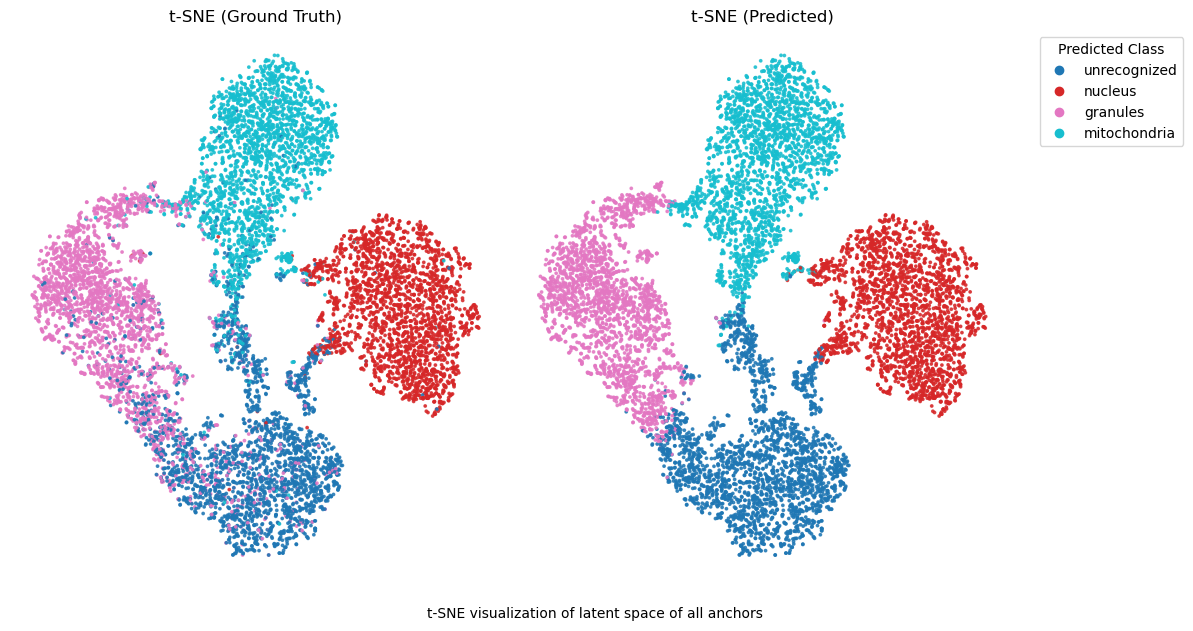

In [4]:
%time Y = tsne.fit(Z_anchors)

fig, axes = plt.subplots(1, 2, figsize=(12,6))

# ---------------- Plot 1: GT labels ----------------
ax = axes[0]
sc = ax.scatter(Y[:,0], Y[:,1], c=label_anchor, cmap="tab10", s=3, alpha=0.8)
ax.set_title("t-SNE (Ground Truth)")
ax.axis("off")

# ---------------- Plot 2: Predicted labels ----------------
ax = axes[1]
sc = ax.scatter(Y[:,0], Y[:,1], c=pred_anchor, cmap="tab10", s=3, alpha=0.8)
ax.set_title("t-SNE (Predicted)")
ax.axis("off")

handles = [plt.Line2D([],[], marker='o', linestyle='', 
                      color=sc.cmap(sc.norm(i)), label=label_names[i]) 
           for i in range(4)]
ax.legend(handles=handles, title="Predicted Class", bbox_to_anchor=(1.05,1), loc="upper left")

fig.text(0.5, -0.02, 
         "t-SNE visualization of latent space of all anchors", 
         ha='center', va='top', fontsize=10)

plt.tight_layout()
plt.show()

--------------------------------------------------------------------------------
TSNE(early_exaggeration=12, n_jobs=8, random_state=42, verbose=True)
--------------------------------------------------------------------------------
===> Finding 90 nearest neighbors using Annoy approximate search using euclidean distance...


   --> Time elapsed: 14.78 seconds
===> Calculating affinity matrix...
   --> Time elapsed: 1.02 seconds
===> Calculating PCA-based initialization...
   --> Time elapsed: 0.02 seconds
===> Running optimization with exaggeration=12.00, lr=5849.08 for 250 iterations...
Iteration   50, KL divergence 5.8534, 50 iterations in 2.6814 sec
Iteration  100, KL divergence 5.6936, 50 iterations in 2.6783 sec
Iteration  150, KL divergence 5.6553, 50 iterations in 2.6433 sec
Iteration  200, KL divergence 5.6403, 50 iterations in 2.6533 sec
Iteration  250, KL divergence 5.6336, 50 iterations in 2.6399 sec
   --> Time elapsed: 13.30 seconds
===> Running optimization with exaggeration=1.00, lr=70189.00 for 500 iterations...
Iteration   50, KL divergence 3.6691, 50 iterations in 2.7652 sec
Iteration  100, KL divergence 3.3973, 50 iterations in 3.5087 sec
Iteration  150, KL divergence 3.2590, 50 iterations in 4.3956 sec
Iteration  200, KL divergence 3.1681, 50 iterations in 5.8388 sec
Iteration  250, KL 

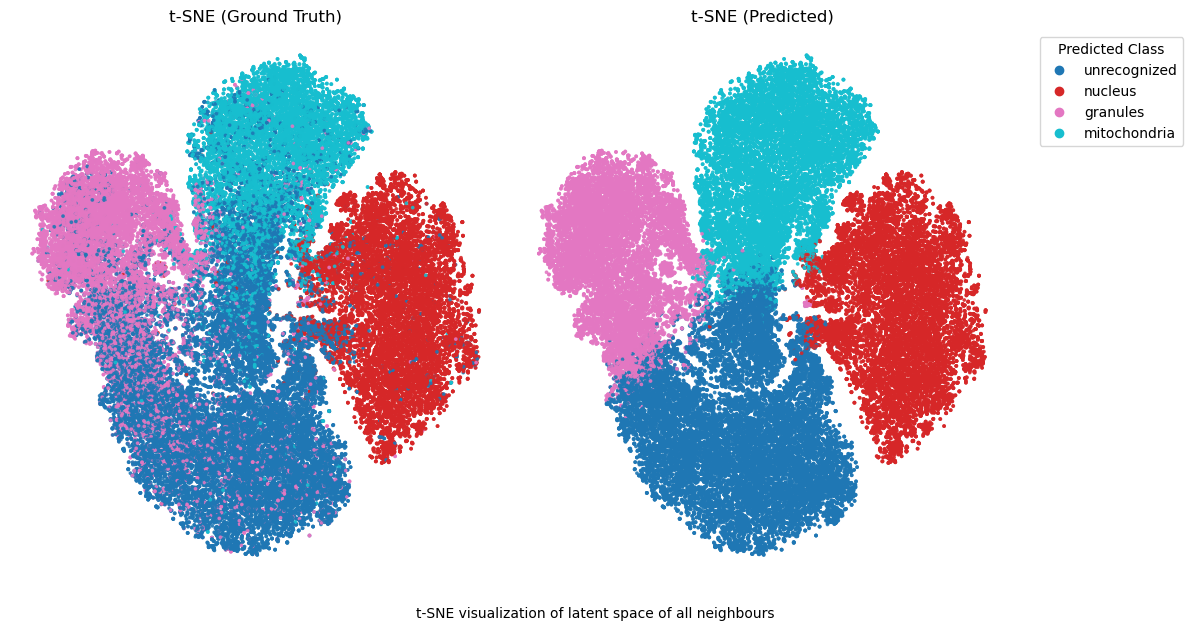

In [5]:
%time Y = tsne.fit(Z_neighbours)

fig, axes = plt.subplots(1, 2, figsize=(12,6))

# ---------------- Plot 1: GT labels ----------------
ax = axes[0]
sc = ax.scatter(Y[:,0], Y[:,1], c=label_neighbour, cmap="tab10", s=3, alpha=0.8)
ax.set_title("t-SNE (Ground Truth)")
ax.axis("off")

# ---------------- Plot 2: Predicted labels ----------------
ax = axes[1]
sc = ax.scatter(Y[:,0], Y[:,1], c=pred_neighbour, cmap="tab10", s=3, alpha=0.8)
ax.set_title("t-SNE (Predicted)")
ax.axis("off")

handles = [plt.Line2D([],[], marker='o', linestyle='', 
                      color=sc.cmap(sc.norm(i)), label=label_names[i]) 
           for i in range(4)]
ax.legend(handles=handles, title="Predicted Class", bbox_to_anchor=(1.05,1), loc="upper left")

fig.text(0.5, -0.02, 
         "t-SNE visualization of latent space of all neighbours", 
         ha='center', va='top', fontsize=10)
cmap_used = sc.cmap
norm_used = sc.norm

plt.tight_layout()
plt.show()

In [6]:
unrec = anchors[anchors['label'] == 0]  # unrecognized anchors
TP_unrec = unrec[unrec['label'] == unrec['pred_label']]  # True Positives 
neighbours_unrec = neighbours[neighbours['anchor_id'].isin(TP_unrec['anchor_id'])]  # neighbours of TP unrecognized anchors

nuc = anchors[anchors['label'] == 1]  # nucleus anchors
TP_nuc = nuc[nuc['label'] == nuc['pred_label']]  # True Positives 
neighbours_nuc = neighbours[neighbours['anchor_id'].isin(TP_nuc['anchor_id'])]  # neighbours of TP nucleus anchors

granules = anchors[anchors['label'] == 2]  # granules anchors
TP_granules = granules[granules['label'] == granules['pred_label']]  # True Positives 
neighbours_granules = neighbours[neighbours['anchor_id'].isin(TP_granules['anchor_id'])]  # neighbours of TP granules anchors

mito = anchors[anchors['label'] == 3]  # mitochondria anchors
TP_mito = mito[mito['label'] == mito['pred_label']]  # True Positives 
neighbours_mito = neighbours[neighbours['anchor_id'].isin(TP_mito['anchor_id'])]  # neighbours of TP mitochondria anchors

TP_anchors = pd.concat([TP_unrec, TP_nuc, TP_granules, TP_mito], ignore_index=True)

In [7]:
tsne_colors = {i: cmap_used(norm_used(i)) for i in range(4)}

# For seaborn (string keys usually safer)
palette_tsne = {str(i): tsne_colors[i] for i in tsne_colors}

In [8]:
def analyze_neighbours(neighbours_df, TP_anchors, class_label, class_name):
    """
    neighbours_df: dataframe of neighbours for the chosen TP anchors
    TP_anchors: dataframe of all TP anchors (for distance computation)
    class_label: int (0..3) for the class being analyzed
    class_name: str for pretty plot titles
    """
    total = len(neighbours_df)
    plt.figure(figsize=(15,5))
    # 1. Distribution of true labels
    ax1 = plt.subplot(1,3,1)
    ax2 = plt.subplot(1,3,2)
    ax3 = plt.subplot(1,3,3)

    # 3. Distribution of closest-anchor labels in latent space
    anchor_latents = np.vstack(TP_anchors['latent'].values)

    closest_labels = []
    latent_dists = []

    for _, row in neighbours_df.iterrows():
        vec = row['latent']
        closest_idx = np.argmin(norm(anchor_latents - vec, axis=1))
        closest_labels.append(TP_anchors.iloc[closest_idx]['label'])

        # store distances for later
        latent_dists.append(norm(anchor_latents[closest_idx] - vec))

    neighbours_df['closest_anchor_label'] = closest_labels
    
    sns.countplot(x='label', data=neighbours_df, palette=palette_tsne,
              order=[0,1,2,3], stat='percent', ax=ax1)
    sns.countplot(x='pred_label', data=neighbours_df, palette=palette_tsne,
                order=[0,1,2,3], stat='percent', ax=ax2)
    sns.countplot(x='closest_anchor_label', data=neighbours_df, palette=palette_tsne,
                order=[0,1,2,3], stat='percent', ax=ax3)

    for ax in (ax1, ax2, ax3):
        ax.set_ylim(0, 100)  # percent scale
        ax.tick_params(axis='y', which='both', left=False, labelleft=False)
        ax.set_ylabel('')
        for p in ax.patches:
            h = p.get_height()           
            ax.annotate(f"{h:.1f}%",
                        (p.get_x() + p.get_width()/2., h),
                        ha='center', va='bottom', fontsize=9)
        for s in ['top','right','bottom','left']:
            ax.spines[s].set_visible(True)
        ax.set_xticks(range(4))
        ax.set_xticklabels([label_names[i] for i in range(4)])
        
    ax1.set_title(f"True labels of neighbours of TP {class_name} anchors")
    ax2.set_title(f"Predicted labels of neighbours of TP {class_name} anchors")
    ax3.set_title(f"Closest TP anchor labels (latent space)")
    

    plt.tight_layout()
    plt.show()

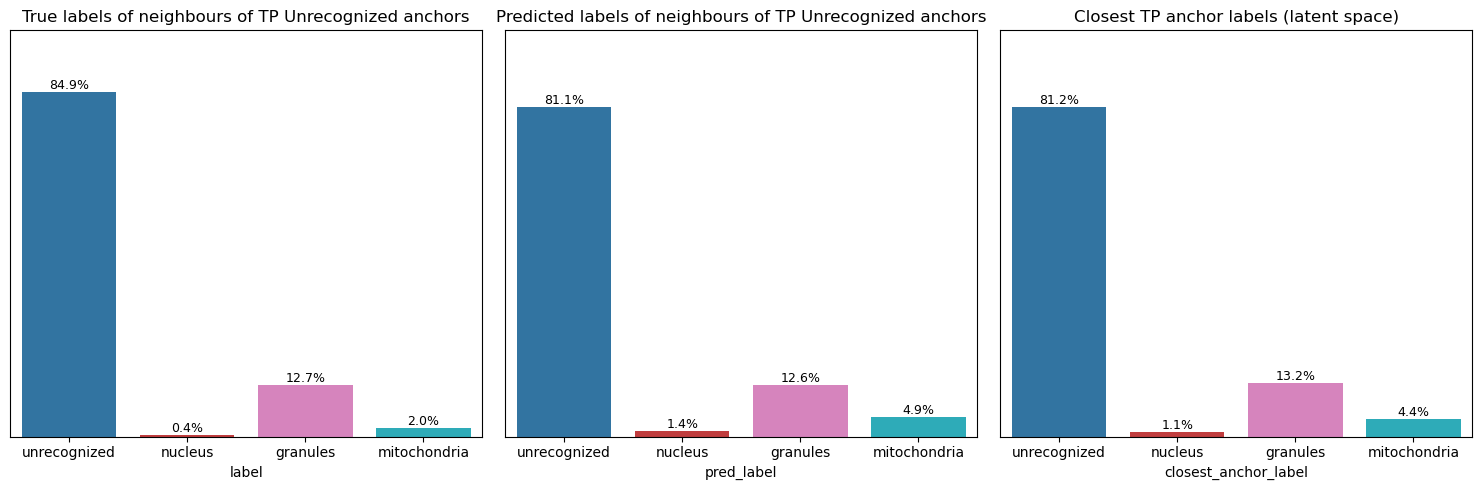

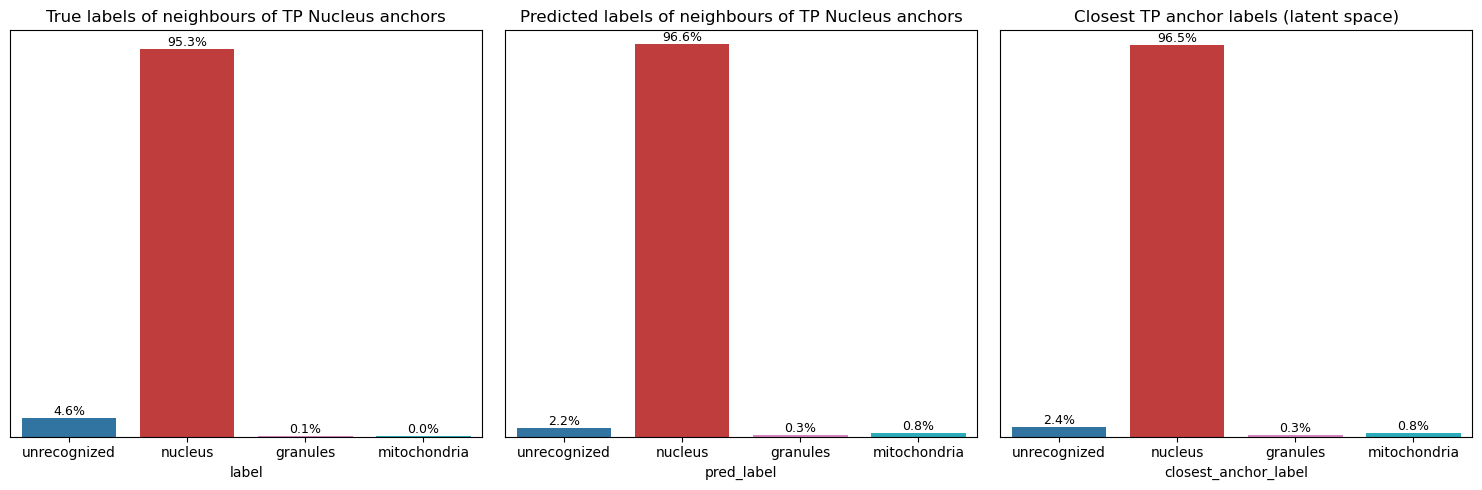

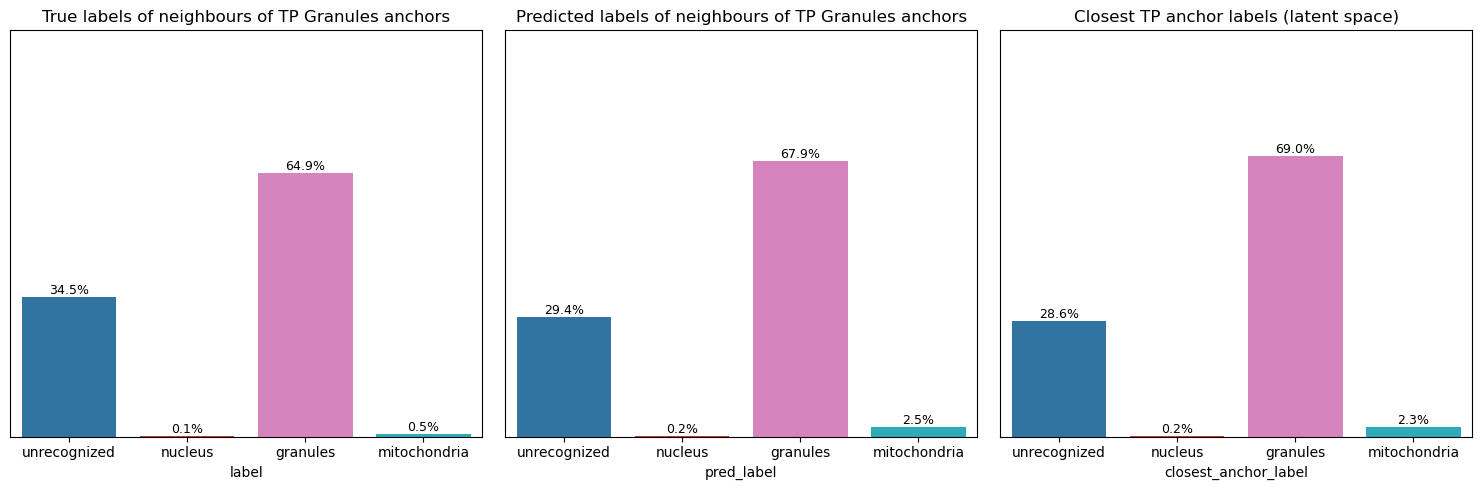

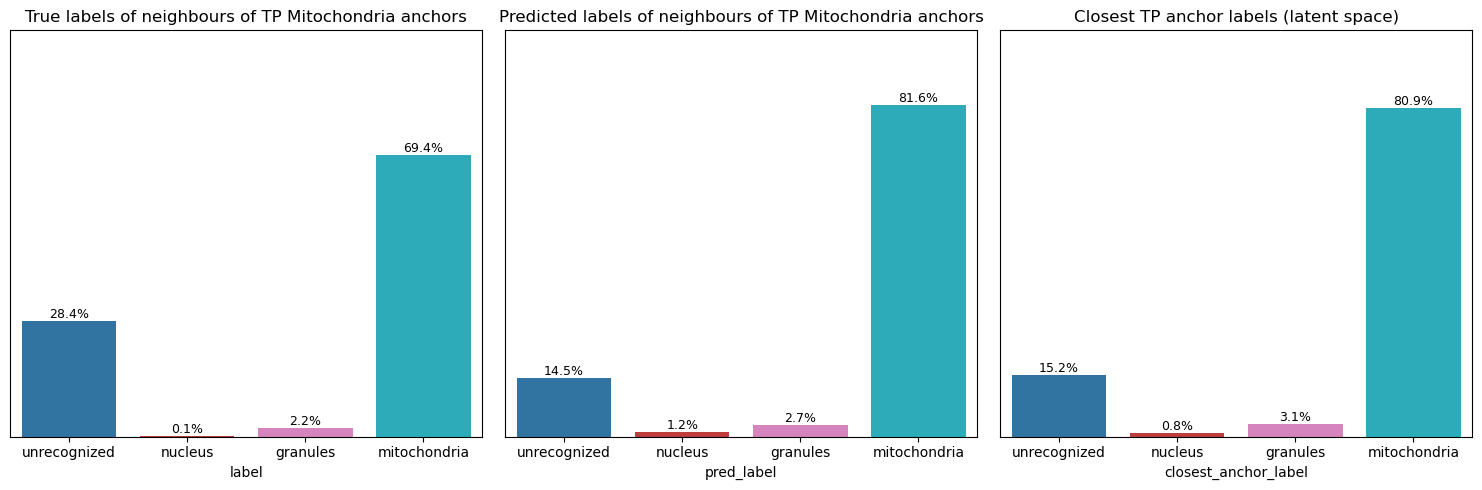

In [9]:
analyze_neighbours(neighbours_unrec, TP_anchors, 0, "Unrecognized")
analyze_neighbours(neighbours_nuc, TP_anchors, 1, "Nucleus")
analyze_neighbours(neighbours_granules, TP_anchors, 2, "Granules")
analyze_neighbours(neighbours_mito, TP_anchors, 3, "Mitochondria")

In [22]:
# Build NN index on TP anchors (latent)
TP_anchor_latents = np.vstack(TP_anchors['latent'].values).astype(np.float32)
TP_anchor_labels  = TP_anchors['label'].values
nn = NearestNeighbors(n_neighbors=1, metric='euclidean')
nn.fit(TP_anchor_latents)

NearestNeighbors(metric='euclidean', n_neighbors=1)

In [11]:
k = 8
knn = NearestNeighbors(n_neighbors=k, metric='euclidean')
knn.fit(TP_anchor_latents)
# stack neighbour latents
neighbours = pd.concat([neighbours_unrec, neighbours_nuc, neighbours_granules, neighbours_mito], ignore_index=True)
neighbours_df = neighbours.copy()  # keep original for output
Z = np.vstack(neighbours_df['latent'].values).astype(np.float32)

# 3-NN in latent among TP anchors
dists, idxs = knn.kneighbors(Z, return_distance=True)       # shapes (M,3)
labk = TP_anchor_labels[idxs]                                # shape (M,3), the 3 labels

all_same = np.all(labk == labk[:, [0]], axis=1)              # (M,)
neighbours_df['k_agreed_label'] = np.where(all_same, labk[:,0], -1).astype(int)


prop_all_same = (neighbours_df['k_agreed_label'] != -1).mean()
print(f"Proportion with all {k}-NN labels identical: {prop_all_same:.3f}")
print(f"Counts by agreed {k}-NN label:")
print(neighbours_df['k_agreed_label'].value_counts(dropna=True).sort_index())

for c in range(4):
    m = (neighbours_df['k_agreed_label'] == c)
    total = m.sum()
    correct = (neighbours_df.loc[m, 'label'] == c).sum()
    pct = correct / total if total else float('nan')
    print(f"class {c}: {correct}/{total} = {pct:.1%}")


Proportion with all 8-NN labels identical: 0.950
Counts by agreed 8-NN label:
k_agreed_label
-1     3201
 0    18356
 1    16392
 2    11797
 3    13884
Name: count, dtype: int64
class 0: 17079/18356 = 93.0%
class 1: 15779/16392 = 96.3%
class 2: 9862/11797 = 83.6%
class 3: 11315/13884 = 81.5%


In [46]:
def latent_distance_distribution(neighbours_df, title=""):

    # --- Neighbour latents & closest TP anchor in latent ---
    neigh_latents = np.vstack(neighbours_df['latent'].values).astype(np.float32)
    dists, idxs = nn.kneighbors(neigh_latents, return_distance=True)
    dists = dists.ravel(); idxs = idxs.ravel()
    closest_anchor_labels = TP_anchor_labels[idxs]
    # check which neghbour's label we predict like closest anchor label

    tmp = neighbours_df.copy()
    tmp['closest_latent_dist']  = dists
    tmp['closest_anchor_label'] = closest_anchor_labels

    # distance to each neighbour's own reference TP anchor
    tp_map = dict(zip(TP_anchors['anchor_id'].values, TP_anchors['latent'].values))
    tmp['own_anchor_latent_dist'] = [
        norm(r['latent'] - tp_map[r['anchor_id']]) for _, r in neighbours_df.iterrows()
    ]

    s = tmp['own_anchor_latent_dist']
    print("min:", s.min(), "max:", s.max())
    print("any negative?", (s < 0).any())

    # if you want to see offending rows (should be none)
    bad = tmp[s < 0]
    print("n negative:", len(bad))
    print(bad.head())

    # optional: also check NaNs / infs and enforce a tiny tolerance
    print("has NaN?", s.isna().any(), "has inf?", np.isinf(s.to_numpy()).any())
    eps = 1e-12
    assert not (s < -eps).any(), f"Found {(s < -eps).sum()} distances < -{eps}"

    # colors
    c_closest = "forestgreen"
    c_own     = "darkorange"
    cmap_fallback = plt.get_cmap("tab10")
    palette_local = {str(i): (palette_tsne[str(i)] if 'palette_tsne' in globals() else cmap_fallback(i))
                     for i in range(4)}

    # ---- PLOTS ----
    fig = plt.figure(figsize=(10,4))
    ax1 = plt.subplot(1,2,1)

    # --- compute means first
    mu_closest = float(np.mean(tmp['closest_latent_dist']))
    mu_own     = float(np.mean(tmp['own_anchor_latent_dist']))

    # KDEs with μ in legend
    sns.kdeplot(tmp['closest_latent_dist'], ax=ax1, linewidth=2, color=c_closest,
                label=rf"to closest anchor ($\mu$={mu_closest:.3f})")
    sns.kdeplot(tmp['own_anchor_latent_dist'], ax=ax1, linewidth=2, color=c_own,
                label=rf"to reference anchor ($\mu$={mu_own:.3f})")

    # guide lines (no text on plot)
    ax1.axvline(mu_closest, color=c_closest, lw=1.6, ls='--', alpha=0.9)
    ax1.axvline(mu_own,     color=c_own,     lw=1.6, ls='--', alpha=0.9)

    ax1.set_title(f"Latent distance distribution\n{title}")
    ax1.legend(frameon=True, framealpha=0.95)

    # Panel 2: by label of closest TP anchor (each label’s μ in legend)
    ax2 = plt.subplot(1,2,2)
    order = [0,1,2,3]
    for lab in order:
        vals = tmp.loc[tmp['closest_anchor_label']==lab, 'closest_latent_dist'].values
        if len(vals) == 0:
            continue
        color = palette_local[str(lab)]
        m = float(np.mean(vals))
        sns.kdeplot(vals, ax=ax2, linewidth=2, color=color,
                    label=rf"{label_names[lab]} ($\mu$={m:.3f})")
        ax2.axvline(m, color=color, lw=1.4, ls='--', alpha=0.9)

    ax2.set_title("Latent distance distribution\nto the closest anchor label")
    ax2.legend(title="Closest anchor", frameon=True, framealpha=0.95)
    # for one axis
    ax1.set_xlabel(None)
    ax1.set_ylabel(None)

    # do the same for ax2
    ax2.set_xlabel(None)
    ax2.set_ylabel(None)
    plt.tight_layout()
    plt.show()

    return tmp[['closest_latent_dist','own_anchor_latent_dist','closest_anchor_label']]


In [47]:
def latent_distance_violin(neighbours_df, title=""):
    # --- Neighbour latents & closest TP anchor in latent ---
    neigh_latents = np.vstack(neighbours_df['latent'].values).astype(np.float32)
    dists, idxs = nn.kneighbors(neigh_latents, return_distance=True)
    dists = dists.ravel(); idxs = idxs.ravel()
    closest_anchor_labels = TP_anchor_labels[idxs]

    tmp = neighbours_df.copy()
    tmp['closest_latent_dist']  = dists
    tmp['closest_anchor_label'] = closest_anchor_labels

    # distance to each neighbour's own reference TP anchor
    tp_map = dict(zip(TP_anchors['anchor_id'].values, TP_anchors['latent'].values))
    tmp['own_anchor_latent_dist'] = [
        norm(r['latent'] - tp_map[r['anchor_id']]) for _, r in neighbours_df.iterrows()
    ]

    # ---- colors/palette ----

    cmap_fallback = plt.get_cmap("tab10")
    palette_local = {str(i): (palette_tsne[str(i)] if 'palette_tsne' in globals() else cmap_fallback(i))
                     for i in range(4)}
    order = [0,1,2,3]

    # ===== PLOTS: 1×3 =====
    fig, (ax2, ax3) = plt.subplots(
        1, 2, figsize=(10,4), gridspec_kw={'width_ratios':[1,1]}
    )

    # (2) per-class KDE (by closest-anchor label)
    for lab in order:
        vals = tmp.loc[tmp['closest_anchor_label']==lab, 'closest_latent_dist'].values
        if len(vals) == 0: continue
        color = palette_local[str(lab)]
        m = float(np.mean(vals))
        sns.kdeplot(vals, ax=ax2, linewidth=2, color=color,
                    label=rf"{label_names[lab]} ($\mu$={m:.3f})")
        ax2.axvline(m, color=color, lw=1.4, ls='--', alpha=0.9)
    ax2.set_title("Latent distance to the closest anchor label")
    ax2.set_xlabel(None); ax2.set_ylabel(None)
    ax2.legend(title="Closest anchor", frameon=True, framealpha=0.95)

    # (3) split violin: does GT match the closest-anchor label?
    tmp['is_match'] = np.where(tmp['label']==tmp['closest_anchor_label'], 'match', 'mismatch')
    # ensure both hue levels exist so split=True works nicely
    tmp['is_match'] = pd.Categorical(tmp['is_match'], categories=['match','mismatch'])

    sns.violinplot(
        data=tmp, x='closest_anchor_label', y='closest_latent_dist',
        order=order,
        hue='is_match', hue_order=['match','mismatch'],
        split=True, inner='quart', cut=0, bw_method='scott',
        palette={'match':'forestgreen', 'mismatch':'crimson'},
        ax=ax3
    )
    ax3.set_xticklabels([label_names[i] for i in order], rotation=0)
    ax3.set_title("Closest distance split by GT==closest?")
    ax3.set_xlabel(None); ax3.set_ylabel(None)
    ax3.legend(title='GT vs closest', bbox_to_anchor=(1.02,1), loc='upper left', frameon=True)

    plt.tight_layout()
    plt.show()

min: 0.0030498125 max: 1.1103278
any negative? False
n negative: 0
Empty DataFrame
Columns: [anchor_id, name, z, y, x, label, neighbor_index, pi, latent, pred_label, closest_anchor_label, closest_latent_dist, own_anchor_latent_dist]
Index: []
has NaN? False has inf? False


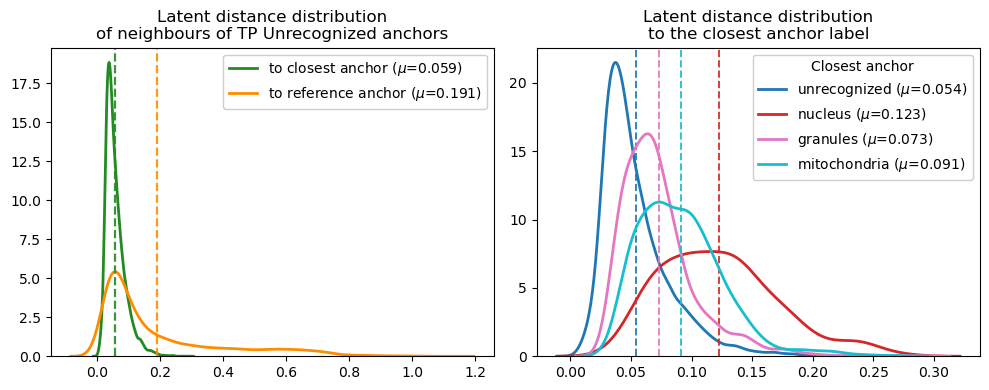

% neighbors whose own anchor is the closest in latent: 17.6%
% neighbors whose closest anchor (latent) is from unrecognized class: 81.2%


In [51]:
unrec_tmp = latent_distance_distribution(neighbours_unrec, title="of neighbours of TP Unrecognized anchors")
own_is_closest = (unrec_tmp['own_anchor_latent_dist'] <= unrec_tmp['closest_latent_dist']).mean()
print(f"% neighbors whose own anchor is the closest in latent: {own_is_closest:.1%}")
prop_closest_unrec = (unrec_tmp['closest_anchor_label'] == 0).mean()
print(f"% neighbors whose closest anchor (latent) is from unrecognized class: {prop_closest_unrec:.1%}")

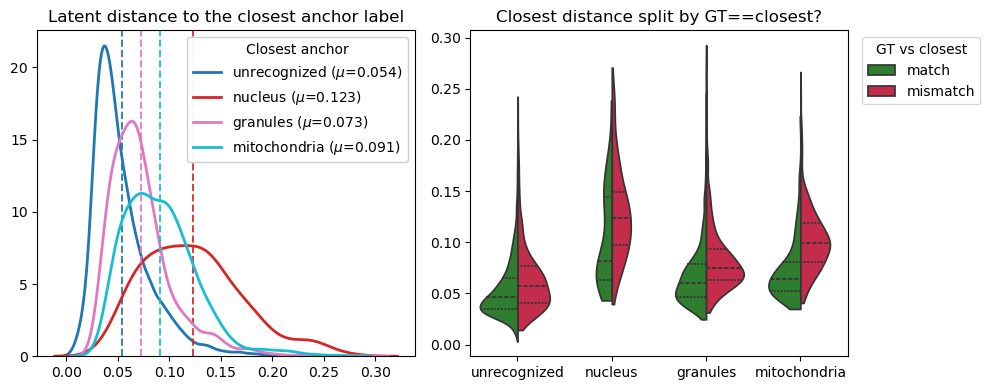

In [52]:
latent_distance_violin(neighbours_unrec, title="of neighbours of TP Unrecognized anchors")

min: 0.0044086976 max: 1.0921738
any negative? False
n negative: 0
Empty DataFrame
Columns: [anchor_id, name, z, y, x, label, neighbor_index, pi, latent, pred_label, closest_anchor_label, closest_latent_dist, own_anchor_latent_dist]
Index: []
has NaN? False has inf? False


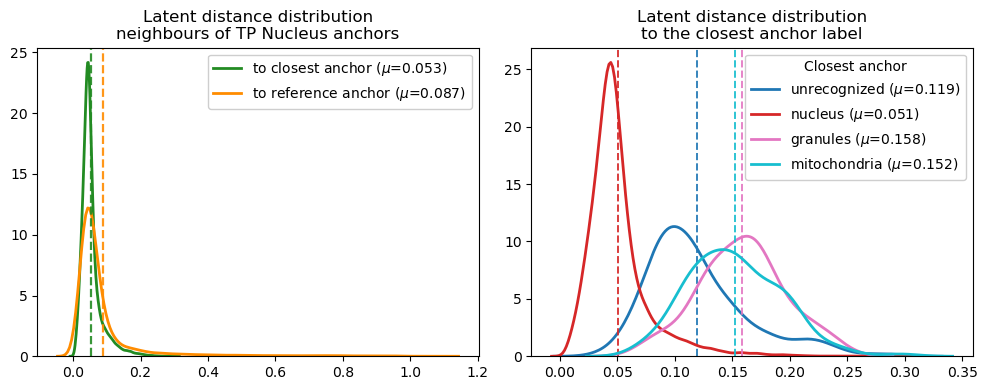

% neighbors whose own anchor is the closest in latent: 43.6%
% neighbors whose closest anchor (latent) is from nucleus class: 96.5%


In [53]:
nuc_tmp = latent_distance_distribution(neighbours_nuc, title="neighbours of TP Nucleus anchors")
own_is_closest = (nuc_tmp['own_anchor_latent_dist'] <= nuc_tmp['closest_latent_dist']).mean()
print(f"% neighbors whose own anchor is the closest in latent: {own_is_closest:.1%}")
prop_closest_unrec = (nuc_tmp['closest_anchor_label'] == 1).mean()
print(f"% neighbors whose closest anchor (latent) is from nucleus class: {prop_closest_unrec:.1%}")

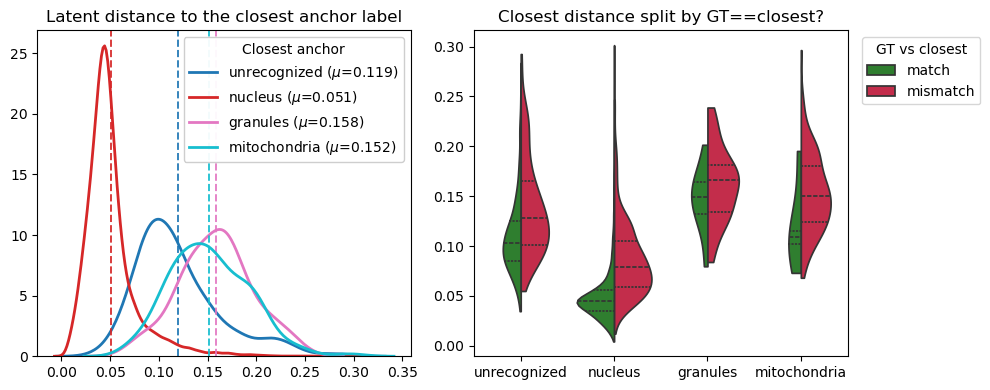

In [54]:
latent_distance_violin(neighbours_nuc, title="neighbours of TP Nucleus anchors")

min: 0.0063004084 max: 1.0114259
any negative? False
n negative: 0
Empty DataFrame
Columns: [anchor_id, name, z, y, x, label, neighbor_index, pi, latent, pred_label, closest_anchor_label, closest_latent_dist, own_anchor_latent_dist]
Index: []
has NaN? False has inf? False


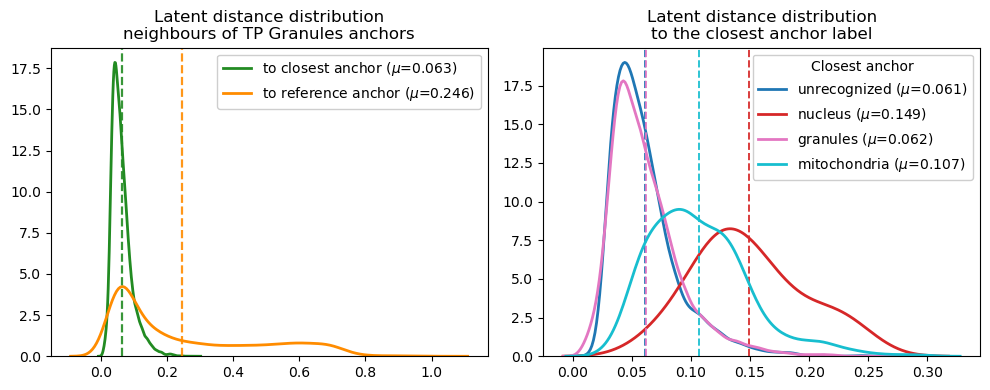

% neighbors whose own anchor is the closest in latent: 15.4%
% neighbors whose closest anchor (latent) is from granules class: 69.0%


In [55]:
gra_tmp = latent_distance_distribution(neighbours_granules, title="neighbours of TP Granules anchors")
own_is_closest = (gra_tmp['own_anchor_latent_dist'] <= gra_tmp['closest_latent_dist']).mean()
print(f"% neighbors whose own anchor is the closest in latent: {own_is_closest:.1%}")
prop_closest_unrec = (gra_tmp['closest_anchor_label'] == 2).mean()
print(f"% neighbors whose closest anchor (latent) is from granules class: {prop_closest_unrec:.1%}")

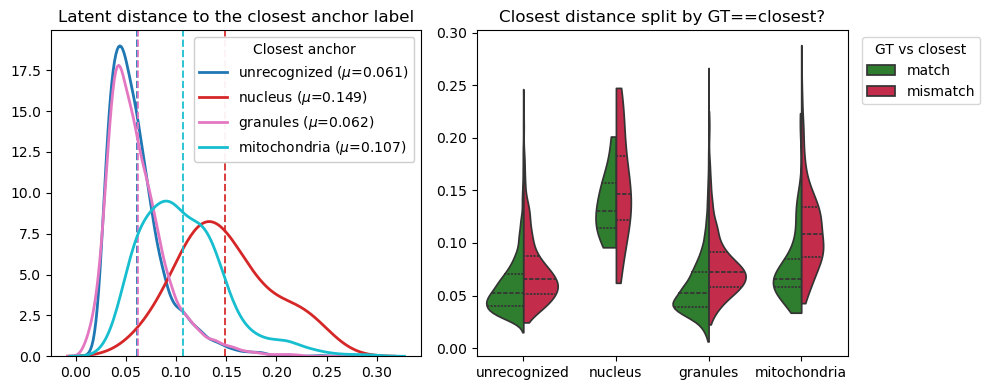

In [56]:
latent_distance_violin(neighbours_granules, title="neighbours of TP Granules anchors")

min: 0.006395934 max: 1.033247
any negative? False
n negative: 0
Empty DataFrame
Columns: [anchor_id, name, z, y, x, label, neighbor_index, pi, latent, pred_label, closest_anchor_label, closest_latent_dist, own_anchor_latent_dist]
Index: []
has NaN? False has inf? False


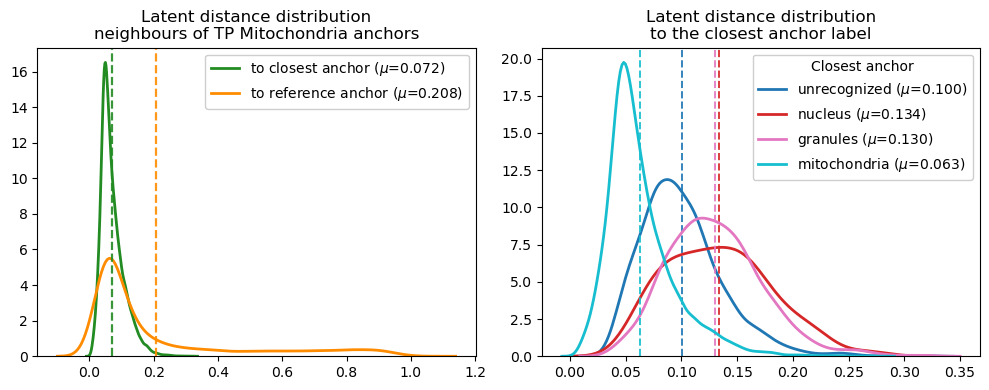

% neighbors whose own anchor is the closest in latent: 26.5%
% neighbors whose closest anchor (latent) is from mitochondria class: 80.9%


In [57]:
mito_tmp = latent_distance_distribution(neighbours_mito, title="neighbours of TP Mitochondria anchors")
own_is_closest = (mito_tmp['own_anchor_latent_dist'] <= mito_tmp['closest_latent_dist']).mean()
print(f"% neighbors whose own anchor is the closest in latent: {own_is_closest:.1%}")
prop_closest_unrec = (mito_tmp['closest_anchor_label'] == 3).mean()
print(f"% neighbors whose closest anchor (latent) is from mitochondria class: {prop_closest_unrec:.1%}")

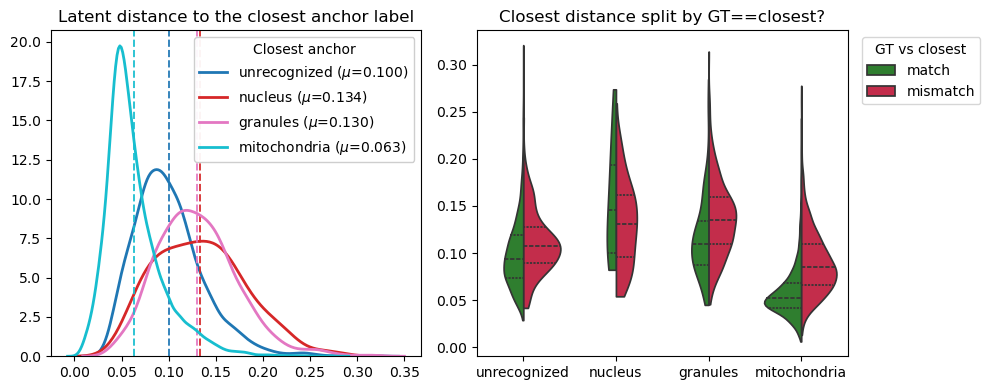

In [58]:
latent_distance_violin(neighbours_mito, title="neighbours of TP Mitochondria anchors")


In [17]:
def describe(v):
    v = np.asarray(v)
    return {
        "n_pairs": len(v),
        "min": float(np.min(v)),
        "median": float(np.median(v)),
        "mean": float(np.mean(v)),
        "p95": float(np.percentile(v, 95)),
    }
def plot_pairwise_latent_distances(d_lat, lbl):
    """
    d_lat: array of pairwise distances in latent space
    """
    _, ax = plt.subplots(figsize=(6,4))
    c0 = (palette_tsne[str(lbl)] if 'palette_tsne' in globals() else plt.get_cmap('tab10')(lbl))

    sns.histplot(d_lat, bins=60, kde=True, color=c0, ax=ax)
    ax.axvline(np.mean(d_lat),   ls='--', lw=1.2, color='k', alpha=0.8, label=f"mean={np.mean(d_lat):.3f}")
    ax.axvline(np.median(d_lat), ls=':',  lw=1.2, color='k', alpha=0.8, label=f"median={np.median(d_lat):.3f}")

    ax.set_title(f"Distribution of pairwise latent distances ({label_names[lbl]})")
    ax.set_xlabel(None)
    ax.set_yticks([])
    ax.set_yticklabels([])
    ax.set_ylabel(None)
    ax.legend()
    
    plt.tight_layout()
    plt.show()

sklearn Latent pairwise stats: {'n_pairs': 2478651, 'min': 0.01586531102657318, 'median': 0.1645742505788803, 'mean': 0.20066094398498535, 'p95': 0.4414049983024597}


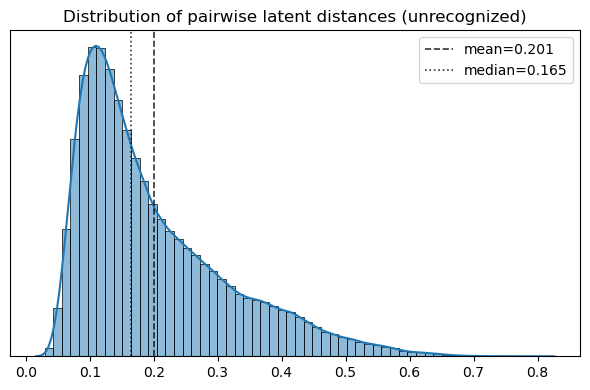

In [18]:
unrec_Z = np.vstack(TP_unrec['latent'].values).astype(np.float32)
D = pairwise_distances(unrec_Z, metric='euclidean')
iu = np.triu_indices_from(D, k=1)
d_lat = D[iu]

print("sklearn Latent pairwise stats:", describe(d_lat))
plot_pairwise_latent_distances(d_lat, 0)

sklearn Latent pairwise stats: {'n_pairs': 2914905, 'min': 0.014747757464647293, 'median': 0.11897801607847214, 'mean': 0.1415124535560608, 'p95': 0.3007013320922851}


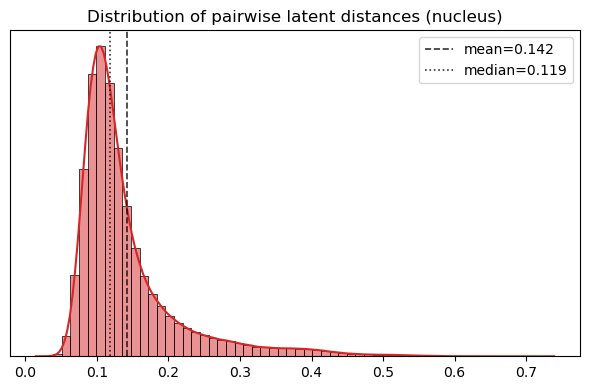

In [19]:
nuc_Z = np.vstack(TP_nuc['latent'].values).astype(np.float32)
D = pairwise_distances(nuc_Z, metric='euclidean')
iu = np.triu_indices_from(D, k=1)
d_lat = D[iu]

print("sklearn Latent pairwise stats:", describe(d_lat))
plot_pairwise_latent_distances(d_lat, 1)

sklearn Latent pairwise stats: {'n_pairs': 2183005, 'min': 0.02599344402551651, 'median': 0.16245263814926147, 'mean': 0.1924501210451126, 'p95': 0.4011590778827665}


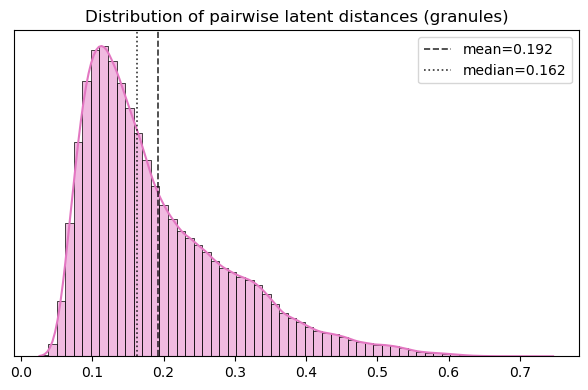

In [20]:
granules_Z = np.vstack(TP_granules['latent'].values).astype(np.float32)
D = pairwise_distances(granules_Z, metric='euclidean')
iu = np.triu_indices_from(D, k=1)
d_lat = D[iu]

print("sklearn Latent pairwise stats:", describe(d_lat))
plot_pairwise_latent_distances(d_lat, 2)

sklearn Latent pairwise stats: {'n_pairs': 2778903, 'min': 0.027311189100146294, 'median': 0.14479102194309235, 'mean': 0.16969530284404755, 'p95': 0.35113819539546964}


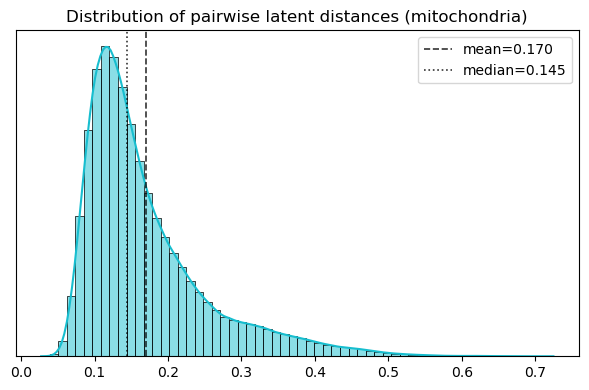

In [21]:
mito_Z = np.vstack(TP_mito['latent'].values).astype(np.float32)
D = pairwise_distances(mito_Z, metric='euclidean')
iu = np.triu_indices_from(D, k=1)
d_lat = D[iu]

print("sklearn Latent pairwise stats:", describe(d_lat))
plot_pairwise_latent_distances(d_lat, 3)